# EDOL dataset


In [41]:
## Importing
import warnings

warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

import numpy as np
from evclust.utils import plotting, display_results_fuzzy_partition, display_results_evidential
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from evclust.datasets import load_edol
import math
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import silhouette_score
from evclust.utils import ev_plot, ev_pcaplot, fcm_pca_plot

from evclust.ecm import ecm
from evclust.wecm_new_barycenter import wecm
from evclust.wecm_new_barycenter_2 import wecm as wecm2
from evclust.gwecm import gwecm
from evclust.wecm2_outlier_weight import wecm as wecm2_outlier
from evclust.fcm.fcm_keller2000 import fcm as fcm_keller2000
from evclust.fcm.fcm_wang2004 import fcm as fcm_wang2004
from evclust.fcm.fcm_frigui2004 import scad1
from evclust.fcm.fcm_frigui2004 import scad2
from evclust.fcm.ifwfcm_xing2014 import fcm as ifwfcm_xing2014
from evclust.fcm.ifwfcm_kd_xing2014 import fcm as ifwfcm_kd_xing2014

In [42]:
def display_evaluation_metrics(X, models, alg="evidential", up_low_appr=True, cex=25):
    if alg == "evidential":
        predicted_labels_list = list(map(lambda model: np.argmax(model['betp'], axis=1), models))
        if up_low_appr:
            ev_plot(models[0], X=X, cex=cex)
        ev_pcaplot(data=X, x=models[0], normalize=False, cex=cex)
    else:
        predicted_labels_list = list(map(lambda model: np.argmax(model['fuzzy_part'], axis=1), models))
        fcm_pca_plot(X, models[0], cex)
    silhouette_scores = [silhouette_score(X, predicted_labels, metric="euclidean") for predicted_labels in predicted_labels_list]
    print(f"Silhoutte Score: {silhouette_scores}")

In [43]:

# fetch dataset
df = load_edol()
X = pd.DataFrame(df.iloc[:, 1:])

# Normalization
scaler = MinMaxScaler(feature_range=(0, 1))
X = pd.DataFrame(scaler.fit_transform(X))

# Perform PCA for dimensionality reduction
pca = PCA(n_components=2)  # Reduce to 2 dimensions
data_reduced = pca.fit_transform(X)
variance_percent = np.round(pca.explained_variance_ratio_ * 100, 1)
# for i in range(data_reduced.shape[0]):
plt.scatter(data_reduced[:, 0], data_reduced[:, 1], alpha=0.5)

sns.pairplot(df, corner=True)

c = 2


## Traditional ECM

In [44]:
# %%capture
# Traditional ECM clustering
delta = np.sqrt(20)
ecm_models = np.array([])
for i in range(10):
    model = ecm(x=X, c=c, beta=2, alpha=1, delta=delta, init="None", epsi=1e-5)
    ecm_models = np.append(ecm_models, model)

ecm_models = sorted(ecm_models, key=lambda x: x['crit'])

[1, 69.34419167288925]
[2, 54.850142982287316]
[3, 52.545484943179105]
[4, 51.62990398672408]
[5, 51.3478269947568]
[6, 51.276573081986704]
[7, 51.260575821048356]
[8, 51.25743149970421]
[9, 51.25700188573063]
[10, 51.2570498230377]
[11, 51.25713309261322]
[12, 51.257187750818545]
[13, 51.25721779667102]
[14, 51.25723332918437]
[15, 51.257241169935355]
[1, 96.19780039153524]
[2, 59.032398108913206]
[3, 53.701414654639045]
[4, 52.038033864748364]
[5, 51.505851783396366]
[6, 51.335558635232196]
[7, 51.28146683520014]
[8, 51.26447049537809]
[9, 51.259240159374414]
[10, 51.257697380937074]
[11, 51.25728276310612]
[12, 51.25719665002361]
[13, 51.25719610153833]
[1, 86.44043551091238]
[2, 55.24786625351681]
[3, 53.349704717092976]
[4, 52.05325313711433]
[5, 51.490055836764036]
[6, 51.31470158588558]
[7, 51.26944288937706]
[8, 51.259162291402006]
[9, 51.257192825988454]
[10, 51.25697997467849]
[11, 51.25705722631866]
[12, 51.25713922181263]
[13, 51.25719050910876]
[14, 51.257218666816954]
[15

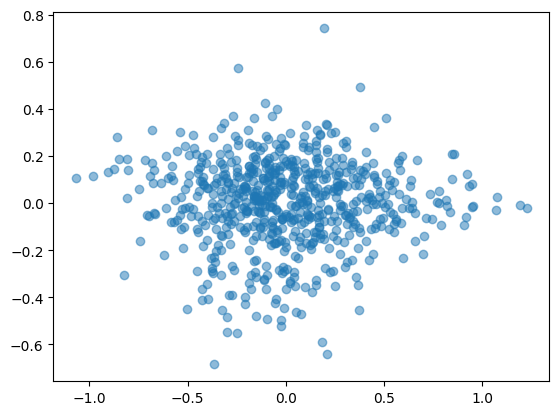

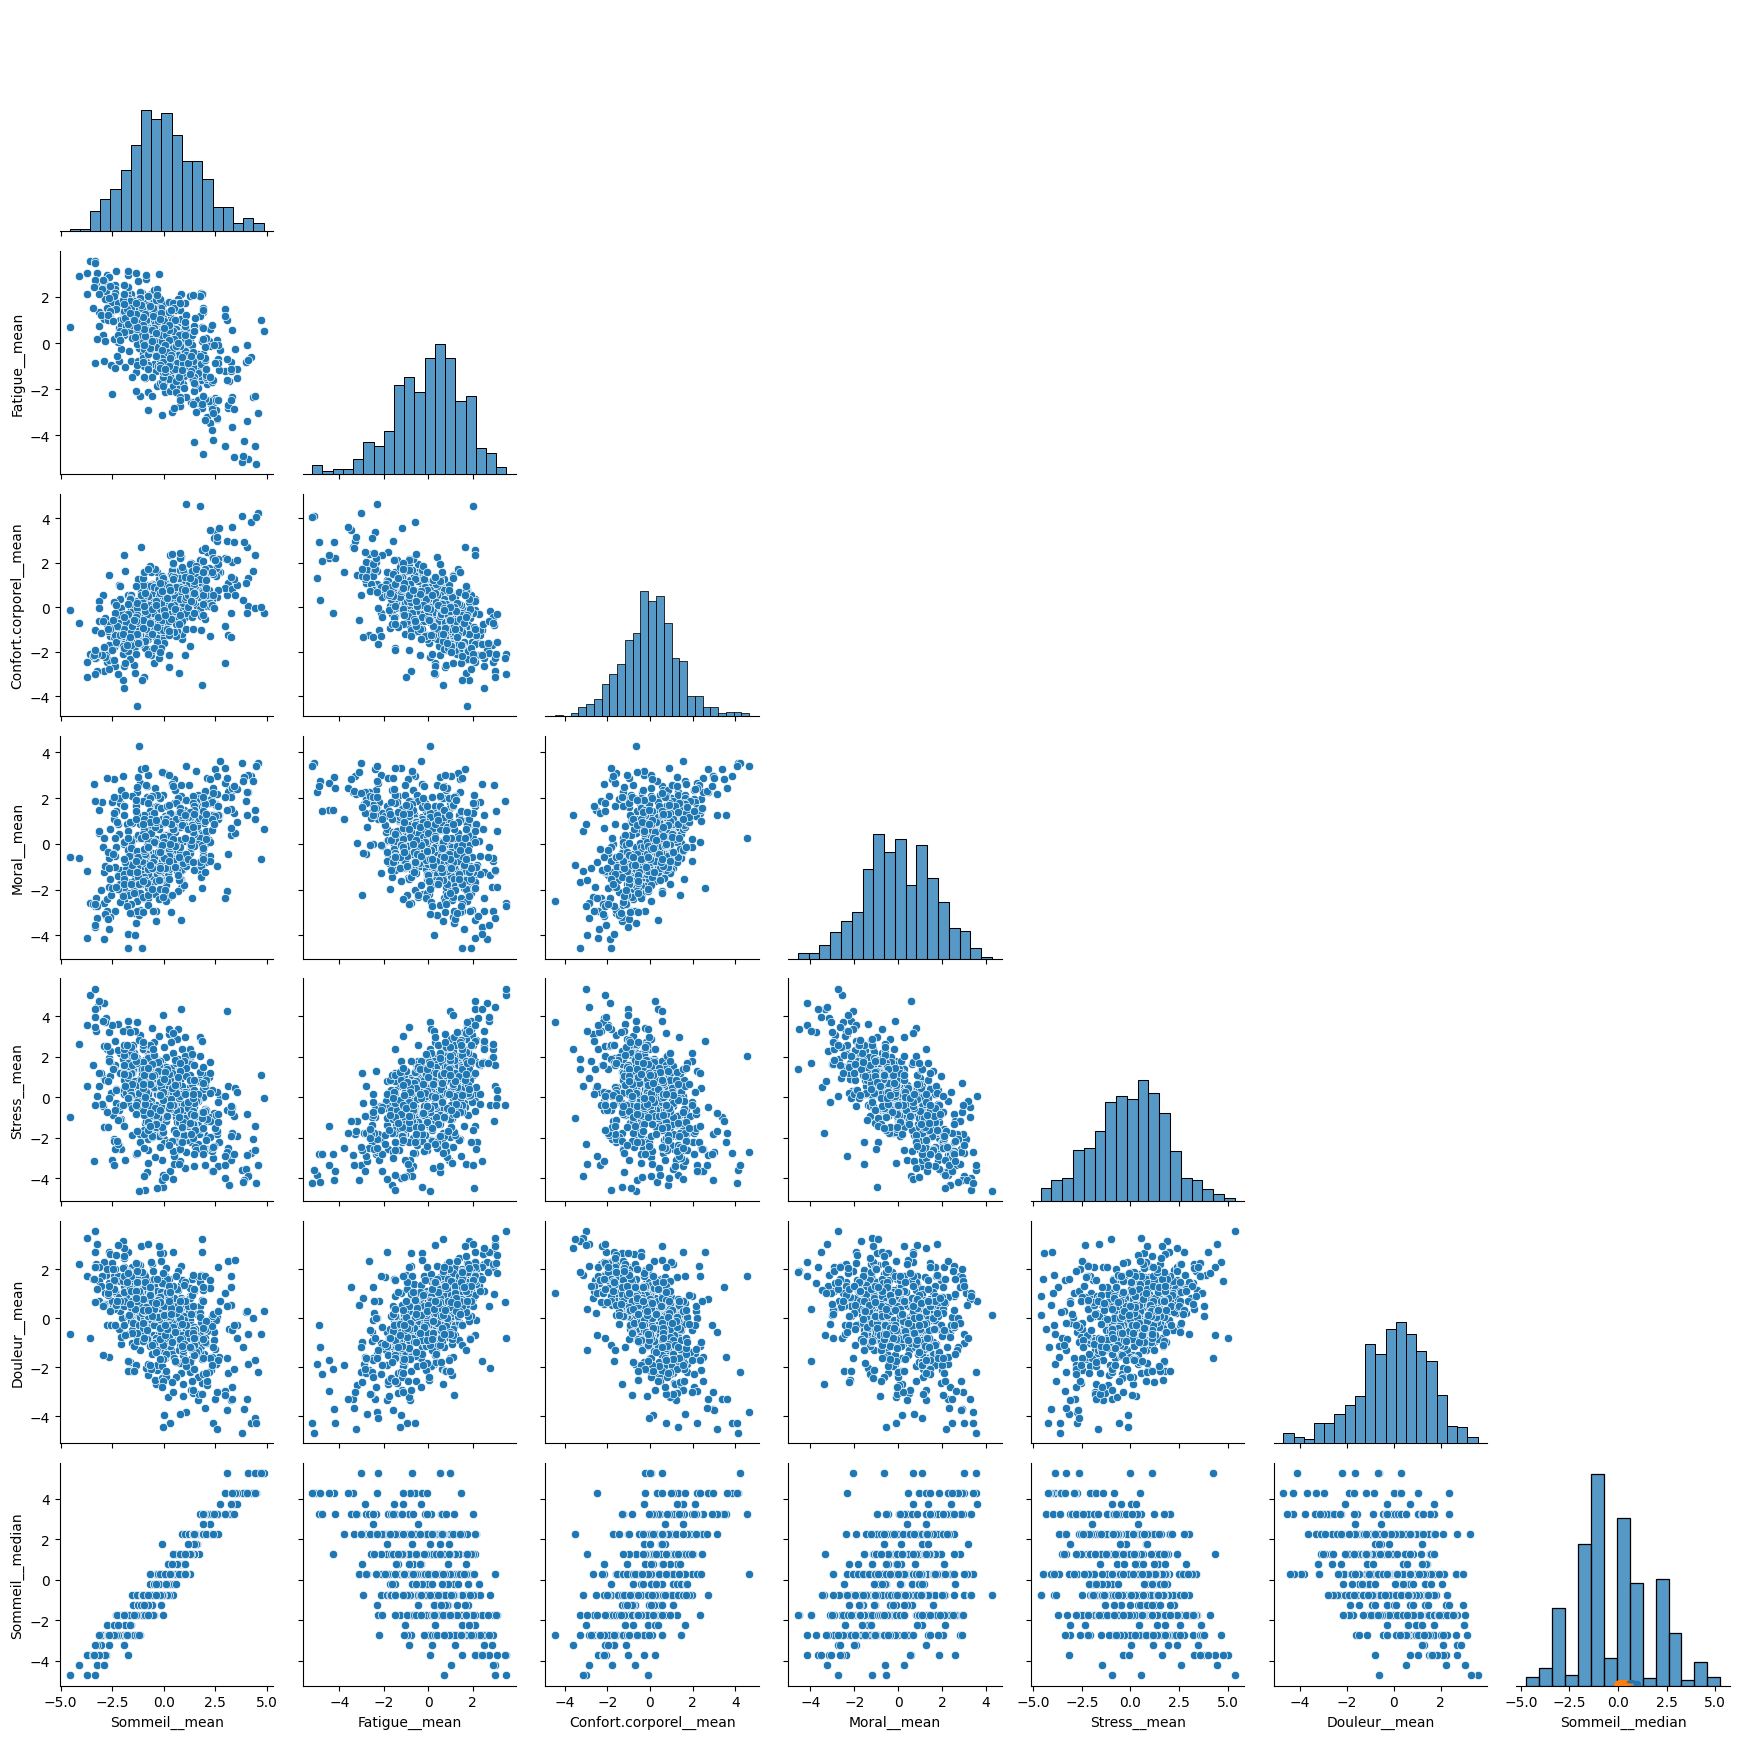

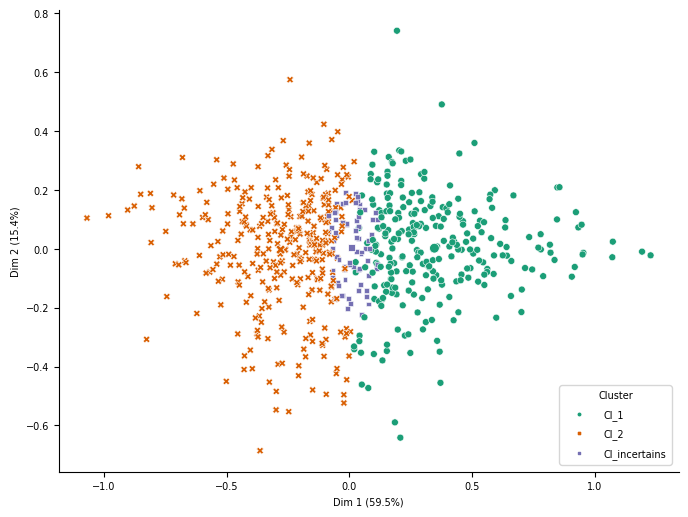

Silhoutte Score: [0.3014125282459449, 0.3014125282459449, 0.3014125282459449, 0.3014125282459449, 0.3014125282459449, 0.3014125282459449, 0.3014125282459449, 0.3014125282459449, 0.3016504212262043, 0.3016504212262043]


In [45]:
display_evaluation_metrics(X, ecm_models)

## Weighted ECM (WECM)

In [46]:
%%capture
wecm_models = np.array([])
d = X.shape[1]
delta = np.sqrt(20)
for i in range(5):
    model = wecm(x=X, c=c, beta=2, alpha=1, delta=delta, stopping_factor="center", init="None")
    wecm_models = np.append(wecm_models, model)

wecm_models = sorted(wecm_models, key=lambda model: model['crit'])

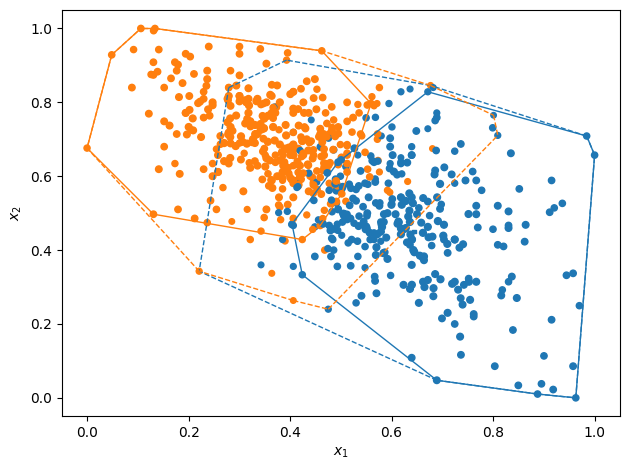

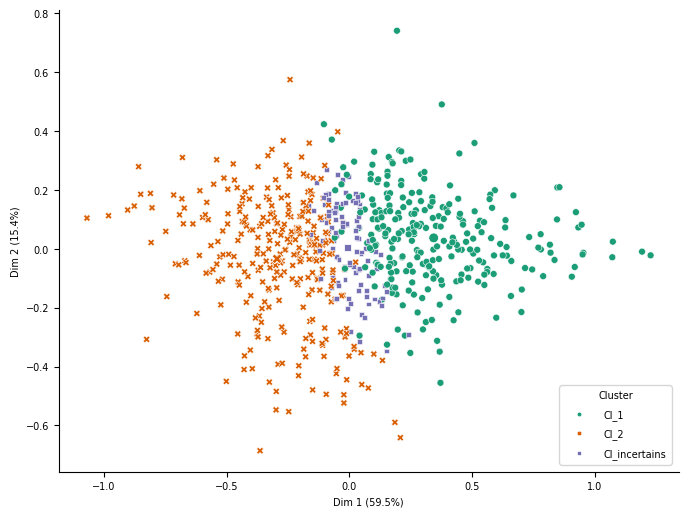

Silhoutte Score: [0.29233350391347196, 0.29277349417852455, 0.29233350391347196, 0.29239335185468684, 0.2919442525807091]


In [47]:
display_evaluation_metrics(X, wecm_models)

## WECM2

In [48]:
%%capture
wecm2_models = np.array([])
d = X.shape[1]
delta = np.sqrt(20)
for i in range(5):
    model = wecm2(x=X, c=c, beta=2, alpha=1, delta=delta, stopping_factor="center", init="None", epsilon=1e-4)
    wecm2_models = np.append(wecm2_models, model)

wecm2_models = sorted(wecm2_models, key=lambda model: model['crit'])

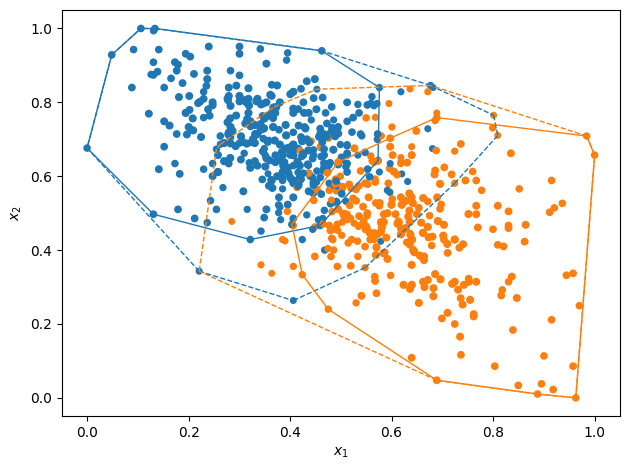

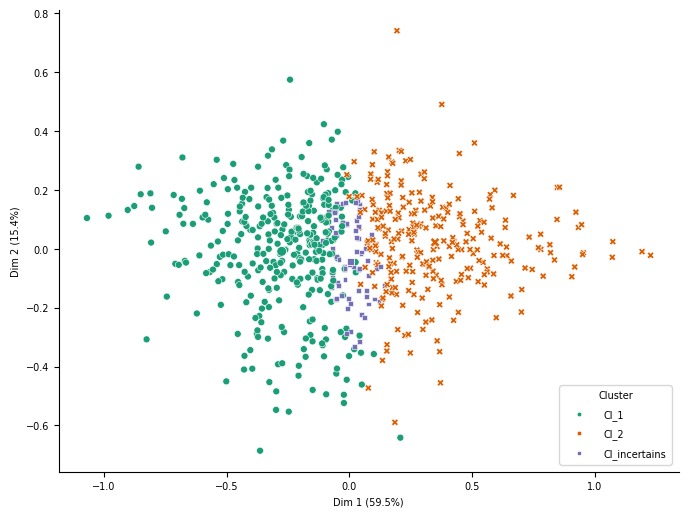

Silhoutte Score: [0.30076788167181184, 0.30076788167181184, 0.30076788167181184, 0.30076788167181184, 0.15622167440122442]


In [49]:
display_evaluation_metrics(X, wecm2_models)

## Global weighted ECM - GWECM

In [50]:
%%capture
gwecm_models = np.array([])
d = X.shape[1]
delta = np.sqrt(20)
for i in range(5):
    model = gwecm(x=X, c=c, gamma=math.e**1, beta=2, alpha=1, delta=delta, stopping_factor="center", init="None", epsilon=1e-4)
    gwecm_models = np.append(gwecm_models, model)

gwecm_models = sorted(gwecm_models, key=lambda model: model['crit'])

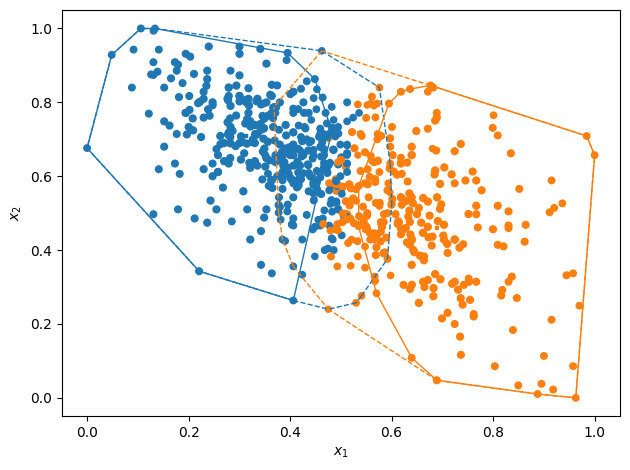

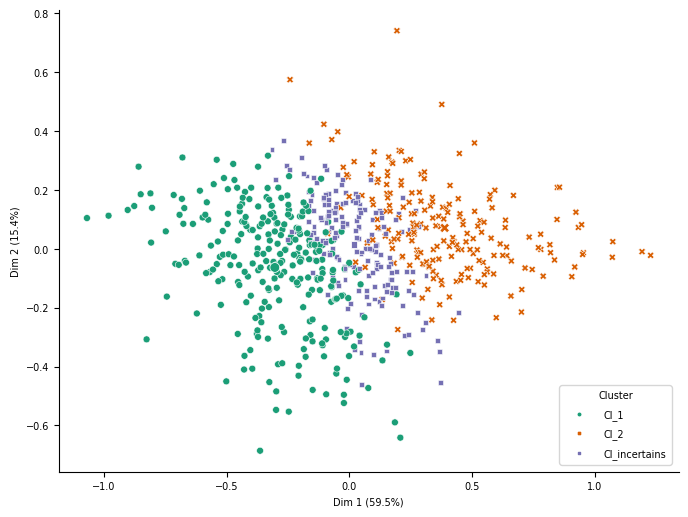

Silhoutte Score: [0.270386130381369, 0.270386130381369, 0.270386130381369, 0.270386130381369, 0.270386130381369]


In [51]:
display_evaluation_metrics(X, gwecm_models)

# Weighted FCM - Keller et al. 2000

In [52]:
%%capture
keller_models = np.array([])
w0 = np.ones((c, X.shape[1])) / X.shape[1]
for i in range(5):
    model = fcm_keller2000(X, c=c, w0=w0, verbose=True, epsilon=1e-6, init="None")
    keller_models = np.append(keller_models, model)
keller_models = sorted(keller_models, key=lambda model: model['obj_func'])

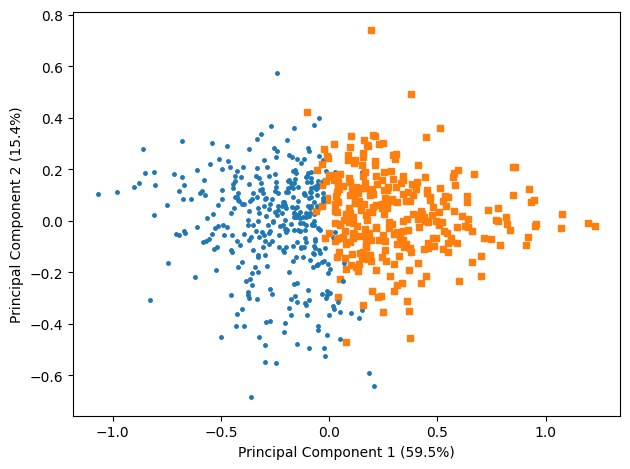

Silhoutte Score: [0.2914447662586705, 0.2913330625992965, 0.2913330625992965, 0.2913330625992965, 0.2913330625992965]


In [53]:
display_evaluation_metrics(X, keller_models, alg="fuzzy")

# Weighted FCM Wang 2004

In [54]:
%%capture
wang_models = np.array([])
for i in range(2):
    model = fcm_wang2004(X, c, w_beta=1.8, verbose=True)
    wang_models = np.append(wang_models, model)
wang_models = sorted(wang_models, key=lambda model: model['obj_func'])

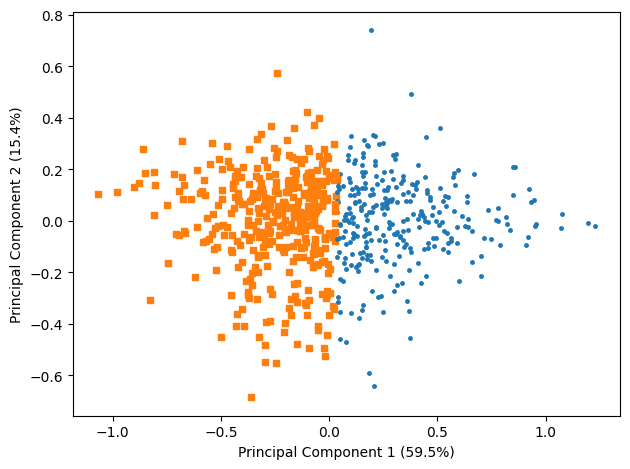

Silhoutte Score: [0.3039698185288808, 0.3039698185288808]


In [55]:
display_evaluation_metrics(X, wang_models, alg="fuzzy")

# SCAD1

In [56]:
%%capture
scad1_models = np.array([])
for i in range(5):
    model = scad1(X, c, verbose=True, K=2, epsilon=1e-6, init="None", stop_factor="Center")
    scad1_models = np.append(scad1_models, model)
scad1_models = sorted(scad1_models, key=lambda model: model['obj_func'])


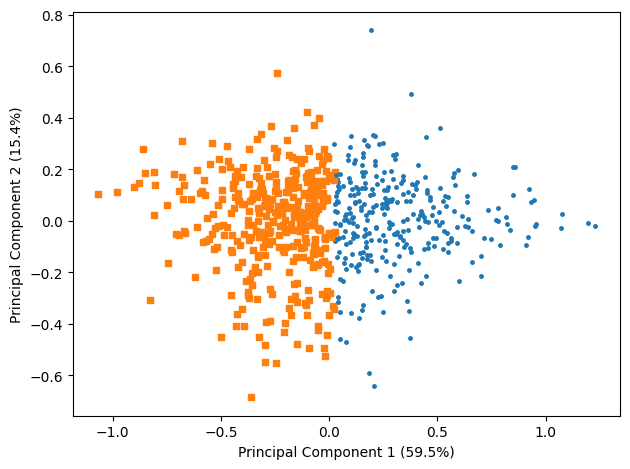

Silhoutte Score: [0.30191709047068754, 0.30191709047068754, 0.30191709047068754, 0.30191709047068754, 0.30191709047068754]


In [57]:
display_evaluation_metrics(X, scad1_models, alg="fuzzy")

# SCAD2

In [58]:
%%capture
scad2_models = np.array([])
for i in range(5):
    model = scad2(X, c, verbose=True, init="None", epsilon=1e-6, stop_factor="center")
    scad2_models = np.append(scad2_models, model)
scad2_models = sorted(scad2_models, key=lambda model: model['obj_func'])


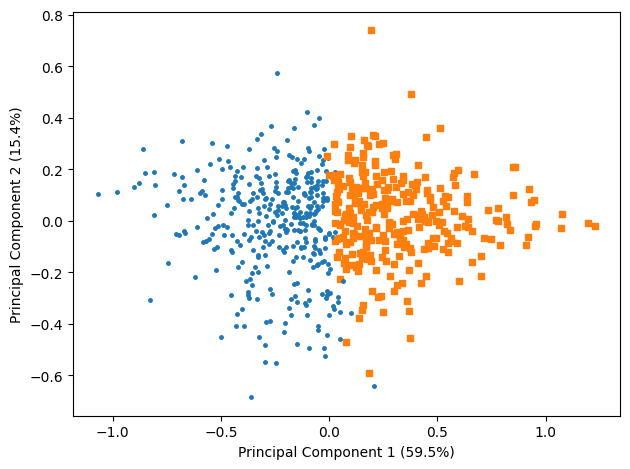

Silhoutte Score: [0.30053943460265076, 0.30053943460265076, 0.30053943460265076, 0.30053943460265076, 0.30053943460265076]


In [59]:
display_evaluation_metrics(X, scad2_models, alg="fuzzy")

# IFWFCM - Xing et al. 2014

In [60]:
%%capture
ifwfcm_models = np.array([])
for i in range(5):
    model = ifwfcm_xing2014(X, c, verbose=True, init="None")
    ifwfcm_models = np.append(ifwfcm_models, model)
ifwfcm_models = sorted(ifwfcm_models, key=lambda model: model['obj_func'])

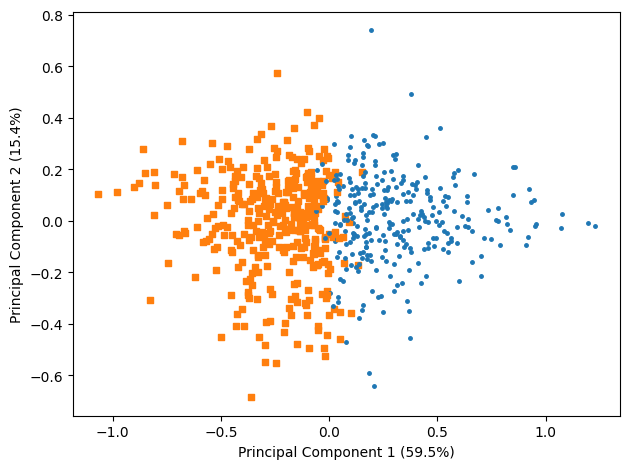

Silhoutte Score: [0.29385836627016565, 0.2940243608431866, 0.29488136239907625, 0.2935321667343292, 0.29456015418081566]


In [61]:
display_evaluation_metrics(X, ifwfcm_models, alg="fuzzy")

# IFWFCM_KD Xing 2014

In [62]:
%%capture
ifwfcm_kd_models = np.array([])
for i in range(5):
    model = ifwfcm_kd_xing2014(X, c, verbose=True, epsilon=1e-6, init="None")
    ifwfcm_kd_models = np.append(ifwfcm_kd_models, model)
ifwfcm_kd_models = sorted(ifwfcm_kd_models, key=lambda model: model['obj_func'])

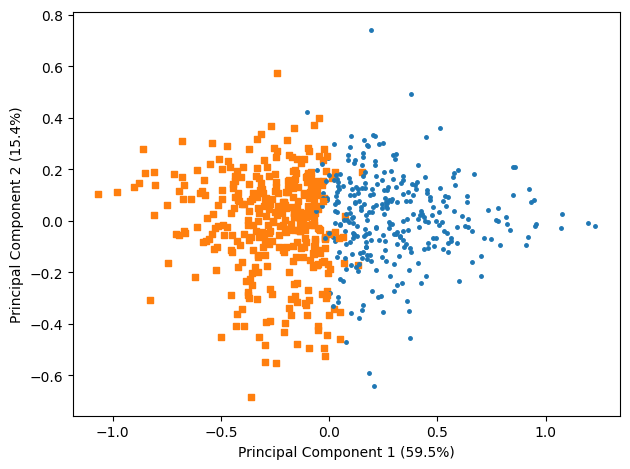

Silhoutte Score: [0.29238748368666073, 0.29238748368666073, 0.29238748368666073, 0.29238748368666073, 0.29238748368666073]


In [63]:
display_evaluation_metrics(X, ifwfcm_kd_models, alg="fuzzy")